In [1]:
import sys
import torch
import torchvision

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA доступна:", torch.cuda.is_available())


Python: c:\Users\acere\AppData\Local\Programs\Python\Python310\python.exe
PyTorch: 2.13.0+cpu
Torchvision: 0.28.0+cpu
CUDA доступна: False


In [2]:
from torchvision import transforms

In [3]:
IMAGE_SIZE = 150

MEAN = (0.5, 0.5, 0.5)
STD = (0.5, 0.5, 0.5)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [4]:
import torch
import torch.nn as nn


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        # Виділення ознак із зображень
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Класифікація знайдених ознак
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleCNN(num_classes=6).to(device)

test_image = torch.randn(1, 3, 150, 150).to(device)

with torch.no_grad():
    test_output = model(test_image)

print(model)
print("Пристрій:", device)
print("Розмір результату:", test_output.shape)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=20736, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [7]:
import torch.optim as optim

# Функція втрат
criterion = nn.CrossEntropyLoss()

# Оптимізатор
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Функція втрат:", criterion)
print("Оптимізатор:", optimizer.__class__.__name__)

Функція втрат: CrossEntropyLoss()
Оптимізатор: Adam


In [9]:
from pathlib import Path

import torch
from torch.utils.data import DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder


# Шляхи до датасету в Kaggle
DATASET_ROOT = Path("./")
TRAIN_DIR = DATASET_ROOT / "seg_train" / "seg_train"
TEST_DIR = DATASET_ROOT / "seg_test" / "seg_test"

print("Train path:", TRAIN_DIR)
print("Test path:", TEST_DIR)

assert TRAIN_DIR.is_dir(), f"Не знайдено папку: {TRAIN_DIR}"
assert TEST_DIR.is_dir(), f"Не знайдено папку: {TEST_DIR}"

Train path: seg_train\seg_train
Test path: seg_test\seg_test


In [10]:
# Цей датасет потрібен для отримання списку файлів та поділу індексів
base_train_dataset = ImageFolder(TRAIN_DIR)

val_size = round(0.2 * len(base_train_dataset))
train_size = len(base_train_dataset) - val_size

generator = torch.Generator().manual_seed(42)

train_split, val_split = random_split(
    base_train_dataset,
    lengths=[train_size, val_size],
    generator=generator
)

# Окремі датасети дозволяють застосувати різні перетворення
train_source = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_source = ImageFolder(
    TRAIN_DIR,
    transform=eval_transform
)

train_dataset = Subset(
    train_source,
    train_split.indices
)

val_dataset = Subset(
    val_source,
    val_split.indices
)

test_dataset = ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

class_names = base_train_dataset.classes

print("Класи:", class_names)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Класи: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 11227
Validation: 2807
Test: 3000


In [11]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

In [12]:
images, labels = next(iter(train_loader))

print("Розмір зображень:", images.shape)
print("Розмір міток:", labels.shape)
print("Мітки першого батча:", labels)

Розмір зображень: torch.Size([32, 3, 150, 150])
Розмір міток: torch.Size([32])
Мітки першого батча: tensor([5, 0, 0, 0, 2, 0, 4, 4, 2, 5, 1, 0, 2, 3, 3, 5, 4, 1, 5, 3, 4, 1, 0, 0,
        2, 2, 2, 4, 4, 4, 4, 2])


In [13]:
from pathlib import Path

NUM_EPOCHS = 10
BEST_MODEL_PATH = Path("best_simple_cnn.pth")

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Навчання
    # -------------------------
    model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Обнуляємо градієнти попереднього кроку
        optimizer.zero_grad()

        # Пряме поширення
        outputs = model(images)

        # Обчислення втрат
        loss = criterion(outputs, labels)

        # Зворотне поширення
        loss.backward()

        # Оновлення ваг
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_accuracy = 100 * train_correct / train_total

    # -------------------------
    # Валідація
    # -------------------------
    model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_accuracy = 100 * val_correct / val_total

    # Зберігаємо показники епохи
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Епоха [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.2f}% | "
        f"Val loss: {val_loss:.4f} | "
        f"Val accuracy: {val_accuracy:.2f}%"
    )

    # Зберігаємо модель із найкращою validation accuracy
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print(
            f"Збережено найкращу модель: "
            f"val accuracy = {best_val_accuracy:.2f}%"
        )

Епоха [1/10] | Train loss: 1.0771 | Train accuracy: 57.37% | Val loss: 0.8483 | Val accuracy: 65.76%
Збережено найкращу модель: val accuracy = 65.76%
Епоха [2/10] | Train loss: 0.8448 | Train accuracy: 68.06% | Val loss: 0.7319 | Val accuracy: 72.21%
Збережено найкращу модель: val accuracy = 72.21%
Епоха [3/10] | Train loss: 0.6945 | Train accuracy: 74.95% | Val loss: 0.5805 | Val accuracy: 78.62%
Збережено найкращу модель: val accuracy = 78.62%
Епоха [4/10] | Train loss: 0.5939 | Train accuracy: 79.32% | Val loss: 0.5617 | Val accuracy: 80.30%
Збережено найкращу модель: val accuracy = 80.30%
Епоха [5/10] | Train loss: 0.5304 | Train accuracy: 81.22% | Val loss: 0.4732 | Val accuracy: 82.94%
Збережено найкращу модель: val accuracy = 82.94%
Епоха [6/10] | Train loss: 0.4798 | Train accuracy: 83.18% | Val loss: 0.5356 | Val accuracy: 81.37%
Епоха [7/10] | Train loss: 0.4454 | Train accuracy: 84.71% | Val loss: 0.4418 | Val accuracy: 84.08%
Збережено найкращу модель: val accuracy = 84.08%

In [14]:
best_weights = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=True
)

model.load_state_dict(best_weights)

print(f"Найкраща validation accuracy: {best_val_accuracy:.2f}%")
print(f"Модель збережена у: {BEST_MODEL_PATH}")

Найкраща validation accuracy: 85.82%
Модель збережена у: best_simple_cnn.pth


In [15]:
best_weights = torch.load(
    "best_simple_cnn.pth",
    map_location=device,
    weights_only=True
)

model.load_state_dict(best_weights)
model.eval()

print("Найкращі ваги моделі завантажено")

Найкращі ваги моделі завантажено


In [16]:
all_labels = []
all_predictions = []

test_loss_sum = 0.0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        predictions = outputs.argmax(dim=1)

        test_loss_sum += loss.item() * images.size(0)
        test_total += labels.size(0)

        all_labels.extend(labels.cpu().tolist())
        all_predictions.extend(predictions.cpu().tolist())

test_loss = test_loss_sum / test_total

print(f"Test loss: {test_loss:.4f}")

Test loss: 0.3975


In [18]:
%pip install -U scikit-learn

     ---------------------------------------- 8.9/8.9 MB 12.1 MB/s eta 0:00:00
     ---------------------------------------- 309.1/309.1 kB ? eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_f1_macro = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

test_f1_weighted = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Macro F1-score: {test_f1_macro:.4f}")
print(f"Weighted F1-score: {test_f1_weighted:.4f}")

print("\nМетрики для кожного класу:")
print(
    classification_report(
        all_labels,
        all_predictions,
        labels=range(len(class_names)),
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Test accuracy: 86.03%
Macro F1-score: 0.8619
Weighted F1-score: 0.8608

Метрики для кожного класу:
              precision    recall  f1-score   support

   buildings     0.7876    0.8741    0.8286       437
      forest     0.9660    0.9578    0.9619       474
     glacier     0.8605    0.8029    0.8307       553
    mountain     0.7851    0.8419    0.8125       525
         sea     0.8845    0.8706    0.8775       510
      street     0.8944    0.8283    0.8601       501

    accuracy                         0.8603      3000
   macro avg     0.8630    0.8626    0.8619      3000
weighted avg     0.8631    0.8603    0.8608      3000



Обґрунтування метрик
Accuracy показує загальну частку правильних прогнозів і добре підходить для нашого відносно збалансованого датасету.
Основною додатковою метрикою варто вибрати Macro F1-score. Вона окремо обчислює F1 для кожного з шести класів, а потім знаходить середнє, надаючи всім класам однакову вагу. Завдяки цьому хороший результат на чисельнішому класі не приховає низьку якість на іншому.
Weighted F1-score враховує кількість зображень кожного класу. Він корисний як додаткова загальна оцінка, але може бути більше орієнтований на чисельніші класи.
Тестовий набір не слід використовувати для підбору параметрів моделі. Зміни моделі потрібно оцінювати на валідаційних даних, а тестові використовувати для фінальної оцінки.

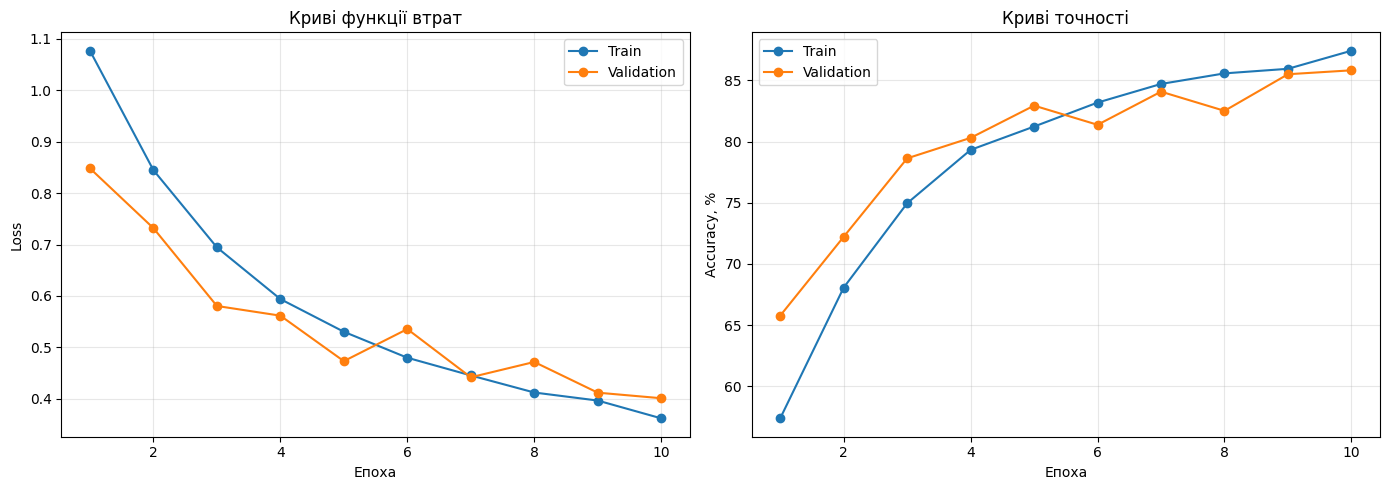

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Графік функції втрат
axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train"
)
axes[0].plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation"
)
axes[0].set_title("Криві функції втрат")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Графік точності
axes[1].plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Train"
)
axes[1].plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation"
)
axes[1].set_title("Криві точності")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("Accuracy, %")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

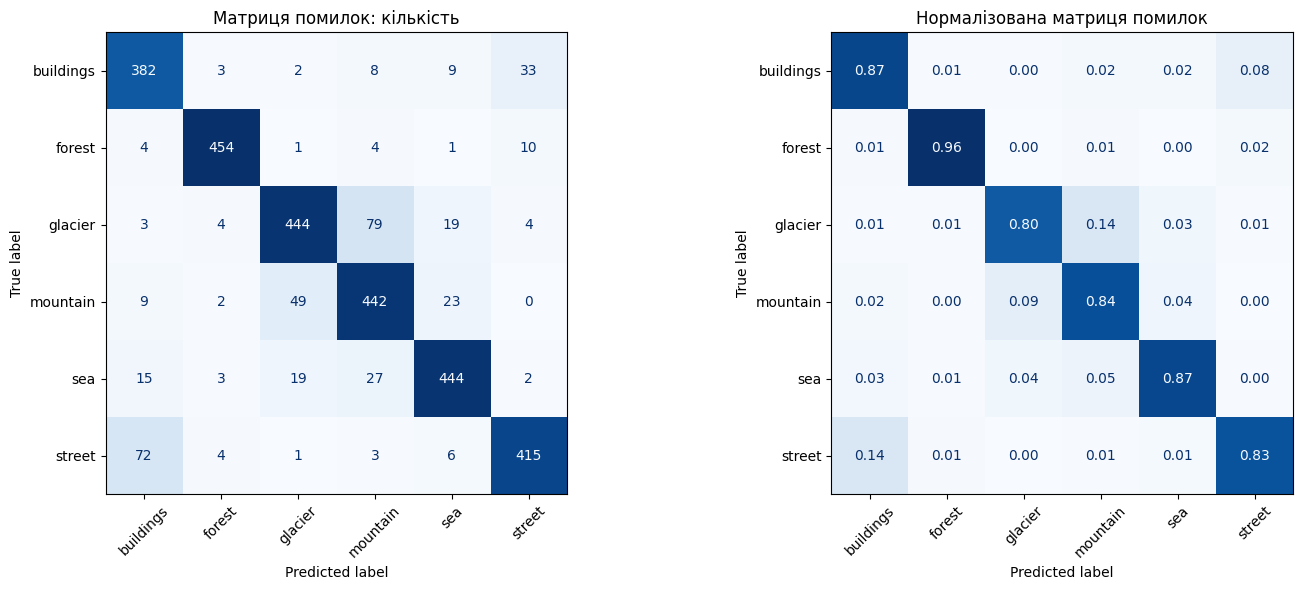

In [21]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

class_indices = range(len(class_names))

confusion_counts = confusion_matrix(
    all_labels,
    all_predictions,
    labels=class_indices
)

confusion_normalized = confusion_matrix(
    all_labels,
    all_predictions,
    labels=class_indices,
    normalize="true"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_counts,
    display_labels=class_names
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    xticks_rotation=45
)
axes[0].set_title("Матриця помилок: кількість")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_normalized,
    display_labels=class_names
).plot(
    ax=axes[1],
    cmap="Blues",
    colorbar=False,
    values_format=".2f",
    xticks_rotation=45
)
axes[1].set_title("Нормалізована матриця помилок")

plt.tight_layout()
plt.show()

In [22]:
confusion_without_diagonal = confusion_counts.copy()

for index in class_indices:
    confusion_without_diagonal[index, index] = 0

error_pairs = []

for true_index in class_indices:
    for predicted_index in class_indices:
        error_count = confusion_without_diagonal[
            true_index,
            predicted_index
        ]

        if error_count > 0:
            error_pairs.append(
                (error_count, true_index, predicted_index)
            )

error_pairs.sort(reverse=True)

print("Найчастіші помилки:")

for count, true_index, predicted_index in error_pairs[:5]:
    print(
        f"{class_names[true_index]} → "
        f"{class_names[predicted_index]}: {count}"
    )

Найчастіші помилки:
glacier → mountain: 79
street → buildings: 72
mountain → glacier: 49
buildings → street: 33
sea → mountain: 27


Перегляд неправильно класифікованих зображень

In [23]:
MAX_ERRORS = 12
misclassified_examples = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        predictions = outputs.argmax(dim=1).cpu()

        for image, true_label, predicted_label in zip(
            images,
            labels,
            predictions
        ):
            if true_label.item() != predicted_label.item():
                misclassified_examples.append(
                    (
                        image.cpu(),
                        true_label.item(),
                        predicted_label.item()
                    )
                )

            if len(misclassified_examples) >= MAX_ERRORS:
                break

        if len(misclassified_examples) >= MAX_ERRORS:
            break

In [24]:
mean = torch.tensor(MEAN).view(3, 1, 1)
std = torch.tensor(STD).view(3, 1, 1)


def denormalize(image):
    image = image * std + mean
    return image.clamp(0, 1)

Візуалізація помилок:

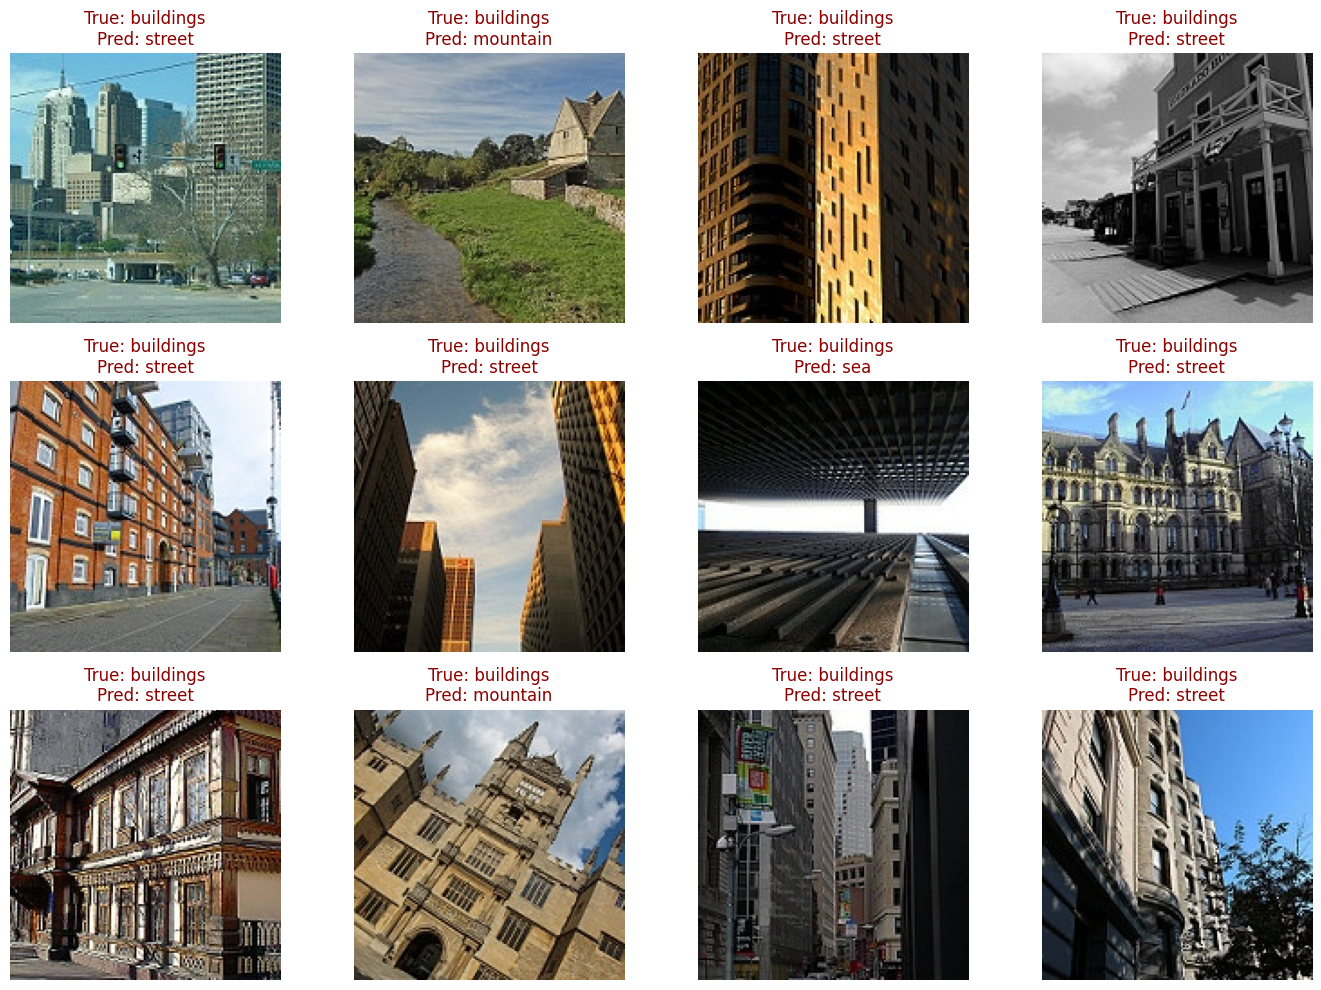

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for axis in axes:
    axis.axis("off")

for axis, example in zip(axes, misclassified_examples):
    image, true_label, predicted_label = example

    image = denormalize(image)
    image = image.permute(1, 2, 0).numpy()

    axis.imshow(image)
    axis.set_title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]}",
        color="darkred"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()